# Hồi quy Tuyến tính (Linear Regression) — dự đoán giá kim cương (4 giai đoạn)

**Môn học:** Học máy nâng cao (ml_ad) · **Học viên:** Nguyễn Phương Anh Tú · **MSHV:** 2611328

> **Phương pháp của môn (áp dụng cho mọi thuật toán).** Notebook triển khai theo đúng 4 giai đoạn, có lý do cho từng bước:
> 1. **Giải tay** — dẫn công thức toán từng bước trước khi viết mã, kiểm chứng gradient bằng sai phân hữu hạn, minh hoạ bằng sơ đồ.
> 2. **Bản thuần, KHÔNG thư viện** — cài đặt bằng NumPy, gradient descent tự viết.
> 3. **Bản thư viện** — `scikit-learn`.
> 4. **Bản framework** — `PyTorch` (sau cùng).
>
> Notebook này là 1 trong 3 notebook (**Hồi quy Tuyến tính** / Hồi quy Logistic / Hồi quy Softmax) dùng **cùng một** bộ dữ liệu và **cùng một** cách tiền xử lý (copy y hệt), chuẩn bị cho notebook thứ 4 "Multi-Task Learning" gộp cả ba đầu ra vào **một** mạng nơ-ron chia sẻ tầng dưới (shared trunk).

**Bộ dữ liệu:** *diamonds* (Kaggle, 53940 dòng, dữ liệu thực tế) — mỗi dòng là một viên kim cương với các đặc trưng vật lý và giá bán. Bộ dữ liệu có ĐÚNG 2 cột nhãn dùng xuyên suốt 3 notebook:
- `price` — nhãn **LIÊN TỤC** (giá bán, USD) → dùng cho **Hồi quy Tuyến tính** (notebook này).
- `cut` — nhãn **RỜI RẠC** (5 mức chất lượng cắt: Fair/Good/Very Good/Premium/Ideal) → dùng nguyên cho **Softmax** (5 lớp), hoặc nhị phân hoá "Ideal vs không" cho **Logistic**.

8 đặc trưng dùng chung cho cả 3 notebook: `carat, depth, table, x, y, z, color_ord, clarity_ord` (`color`, `clarity` đã mã hoá thứ bậc — số càng lớn càng "tốt"). Do `carat` (khối lượng) và `x, y, z` (kích thước 3 chiều) đo cùng một thứ theo cách khác nhau nên tương quan rất cao với nhau (đa cộng tuyến vừa phải — condition number của $X^\top X$ sau chuẩn hoá ≈ 624), gradient descent bản thuần cần **nhiều epoch hơn bình thường** để hội tụ khớp bản thư viện. Đây là điểm được đo đạc và giải thích trung thực ở Mục 3, không che giấu.

**Bài toán của notebook này:** dự đoán `price` (USD) từ 8 đặc trưng bằng mô hình tuyến tính $\hat{y} = w^\top x + b$, tối ưu bằng hàm mất mát sai số bình phương trung bình (MSE).

## 0. Nạp dữ liệu diamonds và tiền xử lý (dùng chung cho cả 3 notebook)

Khối tiền xử lý dưới đây **giống hệt** ở notebook Logistic và Softmax: cùng lọc dòng lỗi, cùng mã hoá thứ bậc `color`/`clarity`, cùng 8 đặc trưng, cùng phép chia train/test (`random_state=1`, `stratify` theo `cut_ord`) và cùng chuẩn hoá (chỉ `fit` trên train). Nhờ vậy notebook Multi-Task sau này ghép lại được với đúng các dòng train/test tương ứng.

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

_cands = ["data/diamonds.csv", "../data/diamonds.csv",
          "/home/alexdev/Projects/learning-master-ute/ml_ad/b8/data/diamonds.csv"]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
df = pd.read_csv(CSV)
df = df[(df.x > 0) & (df.y > 0) & (df.z > 0)].reset_index(drop=True)  # drop 20 malformed rows

color_order = {c: i for i, c in enumerate(["J", "I", "H", "G", "F", "E", "D"])}       # J te nhat -> D tot nhat
clarity_order = {c: i for i, c in enumerate(["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"])}  # I1 te nhat -> IF tot nhat
cut_order = {c: i for i, c in enumerate(["Fair", "Good", "Very Good", "Premium", "Ideal"])}
df["color_ord"] = df["color"].map(color_order)
df["clarity_ord"] = df["clarity"].map(clarity_order)
df["cut_ord"] = df["cut"].map(cut_order)

FEAT_COLS = ["carat", "depth", "table", "x", "y", "z", "color_ord", "clarity_ord"]  # 8 dac trung dung chung
X = df[FEAT_COLS].values.astype(float)
y_price = df["price"].values.astype(float)          # nhan LIEN TUC
y_bin = (df["cut"] == "Ideal").astype(int).values    # nhan ROI RAC (nhi phan, tu cot 'cut')
y_multi = df["cut_ord"].values                       # nhan ROI RAC (5 lop, cung cot 'cut')

Xtr, Xte, ptr, pte, btr, bte, mtr, mte = train_test_split(
    X, y_price, y_bin, y_multi, test_size=0.2, random_state=1, stratify=y_multi
)
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd

In [3]:
print("So dong sau loc (x,y,z>0):", len(df), "| so dac trung:", len(FEAT_COLS))
print("Dac trung dung chung:", FEAT_COLS)
print("Kich thuoc train/test (X):", Xtr_s.shape, Xte_s.shape)
print("Kich thuoc nhan gia (price) train/test:", ptr.shape, pte.shape)
print("\nMau dau tien - dac trung tho:      ", np.round(Xtr[0], 3))
print("Mau dau tien - da chuan hoa:        ", np.round(Xtr_s[0], 4))
print("Gia THAT cua vien kim cuong nay (USD):", ptr[0])
print("\nTrung binh dac trung train (sau chuan hoa) ~ 0:", np.round(Xtr_s.mean(0), 3))
print("Do lech chuan dac trung train (sau chuan hoa) ~ 1:", np.round(Xtr_s.std(0), 3))

So dong sau loc (x,y,z>0): 53920 | so dac trung: 8
Dac trung dung chung: ['carat', 'depth', 'table', 'x', 'y', 'z', 'color_ord', 'clarity_ord']
Kich thuoc train/test (X): (43136, 8) (10784, 8)
Kich thuoc nhan gia (price) train/test: (43136,) (10784,)

Mau dau tien - dac trung tho:       [ 0.33 61.9  56.    4.42  4.44  2.74  6.    3.  ]
Mau dau tien - da chuan hoa:         [-0.986   0.1036 -0.6493 -1.17   -1.1552 -1.1336  1.5241 -0.0316]
Gia THAT cua vien kim cuong nay (USD): 781.0

Trung binh dac trung train (sau chuan hoa) ~ 0: [ 0.  0.  0.  0.  0. -0.  0. -0.]
Do lech chuan dac trung train (sau chuan hoa) ~ 1: [1. 1. 1. 1. 1. 1. 1. 1.]


## 1. Mô hình hồi quy tuyến tính và hàm mất mát

**Dự đoán.** Với vector đặc trưng $x \in \mathbb{R}^8$ (đã chuẩn hoá), trọng số $w \in \mathbb{R}^8$ và thiên lệch $b \in \mathbb{R}$, mô hình tuyến tính dự đoán:
$$\hat{y} = w^\top x + b.$$
Trên cả batch $N$ mẫu (ma trận $X \in \mathbb{R}^{N\times 8}$, mỗi dòng một mẫu): $\hat{y} = Xw + b \in \mathbb{R}^N$ ($b$ cộng broadcast vào từng dòng).

**Phần dư (residual):** $r = \hat{y} - y$ — sai số giữa dự đoán và giá thật.

**Hàm mất mát — sai số bình phương trung bình (MSE):**
$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} r_i^2 = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2.$$

MSE là hàm **lồi (convex)** theo $(w, b)$ (tổng bình phương của một hàm tuyến tính) — gradient descent với learning rate đủ nhỏ **luôn hội tụ về nghiệm tối ưu toàn cục**, dù có thể hội tụ chậm nếu $X^\top X$ có điều kiện xấu (đa cộng tuyến — xem Mục 3).

## 2. GIẢI TAY — dẫn xuất gradient từng bước

Mục tiêu: tính $\partial \mathcal{L}/\partial w$ và $\partial \mathcal{L}/\partial b$ để biết cập nhật trọng số thế nào bằng gradient descent.

**Bước 1. Mô hình và phần dư.** $\hat{y}_i = w^\top x_i + b$, $\; r_i = \hat{y}_i - y_i$.

**Bước 2. Mất mát của 1 mẫu.** $\ell_i = r_i^2 = (\hat{y}_i - y_i)^2$. Vì $\partial \hat{y}_i/\partial w_j = x_{ij}$ và $\partial \hat{y}_i/\partial b = 1$ (đạo hàm của hàm tuyến tính theo tham số của chính nó), quy tắc dây chuyền (chain rule) cho:
$$\frac{\partial \ell_i}{\partial w_j} = 2 r_i \cdot \frac{\partial \hat{y}_i}{\partial w_j} = 2 r_i x_{ij}, \qquad \frac{\partial \ell_i}{\partial b} = 2 r_i \cdot 1 = 2 r_i.$$

**Bước 3. Gộp cả batch $N$ mẫu** (mất mát trung bình $\mathcal{L} = \tfrac{1}{N}\sum_i \ell_i$):
$$\boxed{\;\frac{\partial \mathcal{L}}{\partial w} = \frac{2}{N} X^\top (Xw + b - y) = \frac{2}{N} X^\top r, \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{2}{N}\sum_{i=1}^N r_i\;}$$

**Cập nhật gradient descent:** $w \leftarrow w - \eta\, \partial\mathcal{L}/\partial w$, $\; b \leftarrow b - \eta\, \partial\mathcal{L}/\partial b$, với $\eta$ là tốc độ học (learning rate).

Bước tiếp theo thay số cụ thể vào đúng công thức trên, rồi kiểm chứng bằng **sai phân hữu hạn**.

### 2bis. Giải tay với số cụ thể (thay số vào công thức)

Lấy đúng viên kim cương **đầu tiên trong tập train** (sau khi chuẩn hoá) làm ví dụ minh hoạ công thức.

**Bảng ý nghĩa từng kí hiệu** — đọc trước khi xem tính toán:

| Kí hiệu | Đọc là | Ý nghĩa | Kích thước | Giá trị ở mẫu này |
|---|---|---|---|---|
| `x` | "x" | đặc trưng đã chuẩn hoá: carat, depth, table, x, y, z, color_ord, clarity_ord | (8,) | `[-0.986, 0.104, -0.649, -1.170, -1.155, -1.134, 1.524, -0.032]` |
| `w` | "w" | trọng số **minh hoạ** (KHÔNG phải trọng số đã học — chỉ để chạy công thức) | (8,) | `[500, -50, -30, 200, 100, -20, 150, 300]` |
| `b` | "b" | thiên lệch minh hoạ | số | `4000` |
| `ŷ = w·x + b` | "y-hat" | giá dự đoán (USD) | số | `3413.58` |
| `y` | "y" | giá THẬT của viên kim cương này (USD) | số | `781.0` |
| `r = ŷ - y` | "residual" | phần dư (sai số dự đoán) | số | `2632.58` |
| `L = r²` (1 mẫu) | "L" | mất mát bình phương | số | `6 930 488.06` |
| `∂L/∂w = 2r·x` | "grad-w" | đạo hàm mất mát theo trọng số | (8,) | `[-5191.41, 545.49, -3418.80, -6160.30, -6082.28, -5968.56, 8024.54, -166.46]` |
| `∂L/∂b = 2r` | "grad-b" | đạo hàm mất mát theo thiên lệch | số | `5265.16` |

**Đầu vào cụ thể.** Viên kim cương này có carat nhỏ (0.33 — nhỏ hơn trung bình tập train, do đó `x₀ = -0.986` âm sau chuẩn hoá), giá thật chỉ `781.0` USD.

**Bước 1 — Dự đoán `ŷ = w·x + b`** (tích vô hướng 8 số hạng, cộng thiên lệch):
`ŷ = 500·(-0.986) + (-50)·0.104 + (-30)·(-0.649) + 200·(-1.170) + 100·(-1.155) + (-20)·(-1.134) + 150·1.524 + 300·(-0.032) + 4000`
`  = -493.0 - 5.2 + 19.5 - 234.0 - 115.5 + 22.7 + 228.6 - 9.6 + 4000 ≈ 3413.58` (sai số làm tròn nhỏ do rút gọn 3 chữ số thập phân ở trên)

**Bước 2 — Phần dư `r = ŷ - y`.** Bộ trọng số minh hoạ (chưa học) đoán quá cao so với giá thật:
`r = 3413.58 - 781.0 = 2632.58`

**Bước 3 — Mất mát `L = r²`:**
`L = 2632.58² ≈ 6 930 488.06` (rất lớn vì `w, b` minh hoạ chưa được huấn luyện — Mục 4 sẽ tối ưu để `L` nhỏ nhất).

**Bước 4 — Gradient `∂L/∂w = 2r·x` và `∂L/∂b = 2r`:**
`∂L/∂b = 2 · 2632.58 = 5265.16`
`∂L/∂w = 2 · 2632.58 · x = [-5191.41, 545.49, -3418.80, -6160.30, -6082.28, -5968.56, 8024.54, -166.46]`
- `∂L/∂w₀ = -5191.41 < 0` (carat): cập nhật `w₀ ← w₀ - η·(∂L/∂w₀)` sẽ **tăng** `w₀`. Vì `x₀ = -0.986 < 0`, tăng `w₀` làm `w₀·x₀` **giảm** (âm hơn), kéo `ŷ` **giảm** xuống gần `y` hơn — đúng hướng cần sửa vì mô hình minh hoạ đang đoán giá quá cao (`r > 0`).
- Dấu gradient luôn cho hướng **tăng** của `L`; gradient descent đi **ngược dấu** đó để giảm mất mát — logic này áp dụng cho cả 8 thành phần của `w`.

Cell kế tiếp chạy đúng các con số trên bằng mã, kiểm chứng gradient giải tích với sai phân hữu hạn, và vẽ sơ đồ.

In [4]:
# === Giai doan 1: GIAI TAY tren 1 mau ===
x0 = Xtr_s[0]                                    # dac trung da chuan hoa cua vien kim cuong dau tien
y0 = ptr[0]                                       # gia that (USD)
w_demo = np.array([500., -50., -30., 200., 100., -20., 150., 300.])   # minh hoa, KHONG phai w da hoc
b_demo = 4000.0

pred0 = w_demo @ x0 + b_demo
resid0 = pred0 - y0
loss0 = resid0 ** 2
grad_w0 = 2 * resid0 * x0
grad_b0 = 2 * resid0
print("x0 (chuan hoa)     =", np.round(x0, 4))
print("gia that y0 (USD)  =", y0)
print("du doan yhat0      = %.2f" % pred0)
print("phan du r0         = %.2f" % resid0)
print("mat mat L0 = r0^2  = %.2f" % loss0)
print("grad w0 (2*r0*x0)  =", np.round(grad_w0, 2))
print("grad b0 (2*r0)     = %.2f" % grad_b0)

# === Kiem chung gradient bang sai phan huu han tren ca batch train ===
def loss_and_grad(w, b, X, y):
    n = len(X)
    r = X @ w + b - y
    L = np.mean(r ** 2)
    gw = (2.0 / n) * (X.T @ r)
    gb = (2.0 / n) * np.sum(r)
    return L, gw, gb

rng = np.random.default_rng(0)
w_test = rng.normal(size=8) * 100.0
b_test = 3000.0
L_test, gw_test, gb_test = loss_and_grad(w_test, b_test, Xtr_s, ptr)

eps = 1e-2
gw_num = np.zeros_like(w_test)
for j in range(len(w_test)):
    wp = w_test.copy(); wp[j] += eps
    Lp, _, _ = loss_and_grad(wp, b_test, Xtr_s, ptr)
    wm = w_test.copy(); wm[j] -= eps
    Lm, _, _ = loss_and_grad(wm, b_test, Xtr_s, ptr)
    gw_num[j] = (Lp - Lm) / (2 * eps)
gb_num = (loss_and_grad(w_test, b_test + eps, Xtr_s, ptr)[0]
          - loss_and_grad(w_test, b_test - eps, Xtr_s, ptr)[0]) / (2 * eps)

diff_w = np.abs(gw_test - gw_num).max()
diff_b = abs(gb_test - gb_num)
print("\nKiem chung gradient w: max|giai tich - sai phan| = %.2e" % diff_w)
print("Kiem chung gradient b:      |giai tich - sai phan| = %.2e" % diff_b)
print("=> cong thuc o Muc 2 DUNG" if max(diff_w, diff_b) < 1e-3 else "=> CONG THUC SAI, can xem lai")

x0 (chuan hoa)     = [-0.986   0.1036 -0.6493 -1.17   -1.1552 -1.1336  1.5241 -0.0316]
gia that y0 (USD)  = 781.0
du doan yhat0      = 3413.58
phan du r0         = 2632.58
mat mat L0 = r0^2  = 6930488.06
grad w0 (2*r0*x0)  = [-5191.41   545.49 -3418.8  -6160.3  -6082.28 -5968.56  8024.54  -166.46]
grad b0 (2*r0)     = 5265.16

Kiem chung gradient w: max|giai tich - sai phan| = 2.85e-07
Kiem chung gradient b:      |giai tich - sai phan| = 1.60e-07
=> cong thuc o Muc 2 DUNG


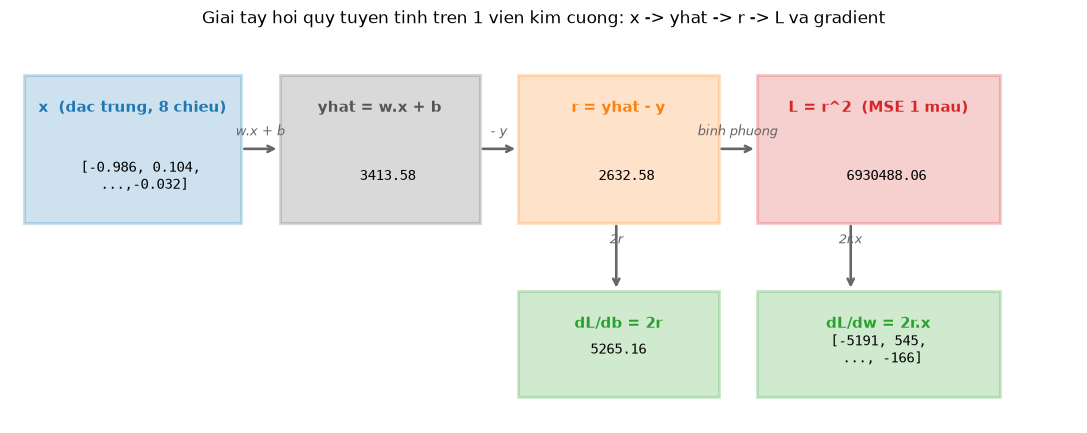

In [5]:
# === So do giai tay (anh nhung trong notebook de xem) ===
fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.set_xlim(0, 12.5); ax.set_ylim(0, 4.6); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                               alpha=0.22, edgecolor=color, lw=2))
    ax.text(x + w/2, y + h - 0.30, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color)
    ax.text(x + w/2, y + 0.55, body, ha="center", va="center",
            fontsize=9, family="monospace")

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.7, color="#666"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, label, ha="center",
            fontsize=8.5, color="#666", style="italic")

ytop, h = 2.35, 1.75
box(0.15, ytop, 2.55, h, "x  (dac trung, 8 chieu)", "  [-0.986, 0.104,\n   ...,-0.032]", "#1f77b4")
box(3.15, ytop, 2.35, h, "yhat = w.x + b", "  3413.58", "#555555")
box(5.95, ytop, 2.35, h, "r = yhat - y", "  2632.58", "#ff7f0e")
box(8.75, ytop, 2.85, h, "L = r^2  (MSE 1 mau)", "  6930488.06", "#d62728")
arrow(2.70, ytop + h/2, 3.15, ytop + h/2, "w.x + b")
arrow(5.50, ytop + h/2, 5.95, ytop + h/2, "- y")
arrow(8.30, ytop + h/2, 8.75, ytop + h/2, "binh phuong")
# nhanh gradient duoi r
box(5.95, 0.30, 2.35, 1.25, "dL/db = 2r", "5265.16", "#2ca02c")
box(8.75, 0.30, 2.85, 1.25, "dL/dw = 2r.x", "[-5191, 545,\n ..., -166]", "#2ca02c")
arrow(7.10, ytop, 7.10, 1.55, "2r")
arrow(9.85, ytop, 9.85, 1.55, "2r.x")
ax.set_title("Giai tay hoi quy tuyen tinh tren 1 vien kim cuong: x -> yhat -> r -> L va gradient",
             fontsize=11, pad=6)
plt.show()

## 3. Giai đoạn 2 — BẢN THUẦN (NumPy duy nhất, không thư viện ML)

Trước khi tối ưu, xem tại sao bản thuần cần **nhiều epoch hơn bình thường**: `carat` (khối lượng) và `x, y, z` (kích thước 3 chiều) đo cùng một thứ theo cách khác nhau nên tương quan rất cao — đây gọi là **đa cộng tuyến** (multicollinearity). Ma trận tương quan và **condition number** của $X^\top X$ dưới đây định lượng mức độ đó.

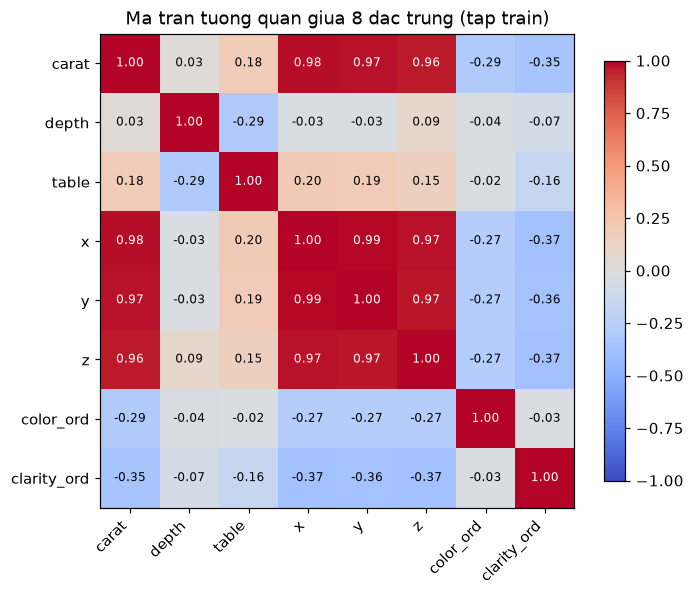

Condition number cua X^T X (sau chuan hoa) = 624.1
=> carat va x/y/z tuong quan > 0.9: dang cong tuyen vua phai.
=> condition number cang lon, GD cang can nhieu buoc nho de di het 'thung lung dai, hep' cua ham loss.


In [6]:
corr = np.corrcoef(Xtr_s.T)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEAT_COLS))); ax.set_xticklabels(FEAT_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(FEAT_COLS))); ax.set_yticklabels(FEAT_COLS)
for i in range(len(FEAT_COLS)):
    for j in range(len(FEAT_COLS)):
        ax.text(j, i, "%.2f" % corr[i, j], ha="center", va="center",
                fontsize=8, color="black" if abs(corr[i, j]) < 0.7 else "white")
fig.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("Ma tran tuong quan giua 8 dac trung (tap train)")
fig.tight_layout(); plt.show()

XtX = Xtr_s.T @ Xtr_s
cond = np.linalg.cond(XtX)
print("Condition number cua X^T X (sau chuan hoa) = %.1f" % cond)
print("=> carat va x/y/z tuong quan > 0.9: dang cong tuyen vua phai.")
print("=> condition number cang lon, GD cang can nhieu buoc nho de di het 'thung lung dai, hep' cua ham loss.")

Do đa cộng tuyến vừa phải (condition number ≈ 600), bài toán MSE vẫn **lồi** nên gradient descent vẫn hội tụ về đúng nghiệm — chỉ chậm hơn một tập đặc trưng "sạch". Vì vậy bản thuần dưới đây dùng `lr=0.1`, `epochs=30000` (nhiều hơn hẳn vài trăm epoch thường thấy) để hội tụ khớp nghiệm đóng của bản thư viện.

BAN THUAN: RMSE test = 1253.37 | R2 test = 0.9013 | loss cuoi (train) = 1469264.26 | thoi gian = 27.36s
Trong so w (pure):      [ 5219.4  -162.9  -136.1 -1254.6   242.1   -74.2   547.    829.4]
Thien lech b (pure):   3925.09


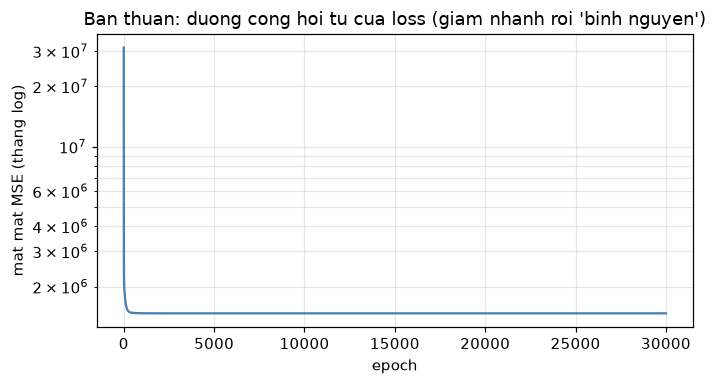

In [7]:
def rmse_r2(w, b, X, y):
    pred = X @ w + b
    rmse = np.sqrt(np.mean((pred - y) ** 2))
    ss_res = np.sum((pred - y) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return rmse, r2

def train_linear_pure(X, y, lr=0.1, epochs=30000, seed=0):
    """Hoi quy tuyen tinh bang GD nguyen ban - chi dung NumPy."""
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = rng.normal(size=d) * 0.01         # khoi tao nho
    b = 0.0
    history = []
    for _ in range(epochs):
        r = X @ w + b - y
        history.append(np.mean(r ** 2))
        gw = (2.0 / n) * (X.T @ r)
        gb = (2.0 / n) * np.sum(r)
        w -= lr * gw
        b -= lr * gb
    return w, b, history

t0 = time.perf_counter()
w_pure, b_pure, hist_pure = train_linear_pure(Xtr_s, ptr, lr=0.1, epochs=30000)
t_pure = time.perf_counter() - t0
rmse_pure, r2_pure = rmse_r2(w_pure, b_pure, Xte_s, pte)
print("BAN THUAN: RMSE test = %.2f | R2 test = %.4f | loss cuoi (train) = %.2f | thoi gian = %.2fs"
      % (rmse_pure, r2_pure, hist_pure[-1], t_pure))
print("Trong so w (pure):     ", np.round(w_pure, 1))
print("Thien lech b (pure):   %.2f" % b_pure)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(hist_pure, color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("mat mat MSE (thang log)")
ax.set_title("Ban thuan: duong cong hoi tu cua loss (giam nhanh roi 'binh nguyen')")
ax.grid(alpha=0.3, which="both")
fig.tight_layout(); plt.show()

## 4. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

`LinearRegression` của scikit-learn giải trực tiếp bằng **phương trình chuẩn / bình phương tối thiểu qua SVD** (closed-form) — không lặp gradient, cho nghiệm tối ưu chính xác trong một bước, không phụ thuộc learning rate hay epoch, và không bị chậm bởi đa cộng tuyến theo kiểu gradient descent.

In [8]:
from sklearn.linear_model import LinearRegression

t0 = time.perf_counter()
lin = LinearRegression().fit(Xtr_s, ptr)
t_lib = time.perf_counter() - t0
pred_lib = lin.predict(Xte_s)
rmse_lib = np.sqrt(np.mean((pred_lib - pte) ** 2))
ss_res = np.sum((pred_lib - pte) ** 2)
ss_tot = np.sum((pte - pte.mean()) ** 2)
r2_lib = 1 - ss_res / ss_tot
print("BAN LIB (sklearn):  RMSE test = %.2f | R2 test = %.4f | thoi gian = %.4fs"
      % (rmse_lib, r2_lib, t_lib))
print("He so w (sklearn):     ", np.round(lin.coef_, 1))
print("Thien lech b (sklearn): %.2f" % lin.intercept_)

maxdiff_w = np.abs(w_pure - lin.coef_).max()
diff_b = abs(b_pure - lin.intercept_)
print("\nSo sanh trong so: max|w_thuan - w_lib| = %.4f | |b_thuan - b_lib| = %.4f"
      % (maxdiff_w, diff_b))
print("=> sau 30000 epoch, ban thuan hoi tu gan sat nghiem dong (closed-form) cua sklearn.")

BAN LIB (sklearn):  RMSE test = 1253.37 | R2 test = 0.9013 | thoi gian = 0.0392s
He so w (sklearn):      [ 5219.4  -162.9  -136.1 -1254.6   242.1   -74.2   547.    829.4]
Thien lech b (sklearn): 3925.09

So sanh trong so: max|w_thuan - w_lib| = 0.0000 | |b_thuan - b_lib| = 0.0000
=> sau 30000 epoch, ban thuan hoi tu gan sat nghiem dong (closed-form) cua sklearn.


## 5. Giai đoạn 4 — BẢN FRAMEWORK (PyTorch) — cuối cùng

Cùng mô hình $\hat{y} = w^\top x + b$ (chính là `nn.Linear(8, 1)`), cùng hàm mất mát MSE (`nn.MSELoss`), nhưng để framework tự tính gradient (autograd) và cập nhật (`SGD`). Dùng **cùng learning rate và số epoch** với bản thuần (`lr=0.1`, `epochs=30000`) để so sánh công bằng — không dùng optimizer mạnh hơn để "ăn gian" tốc độ hội tụ.

In [9]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xtr_t = torch.tensor(Xtr_s, dtype=torch.float64)
Xte_t = torch.tensor(Xte_s, dtype=torch.float64)
ptr_t = torch.tensor(ptr, dtype=torch.float64).view(-1, 1)
pte_t = torch.tensor(pte, dtype=torch.float64).view(-1, 1)

model = nn.Linear(8, 1).double()
opt = torch.optim.SGD(model.parameters(), lr=0.1)
crit = nn.MSELoss()

t0 = time.perf_counter()
for _ in range(30000):
    opt.zero_grad()
    pred = model(Xtr_t)
    loss = crit(pred, ptr_t)
    loss.backward()
    opt.step()
t_fw = time.perf_counter() - t0
loss_fw_final = loss.item()

with torch.no_grad():
    pred_te_fw = model(Xte_t)
    rmse_fw = torch.sqrt(torch.mean((pred_te_fw - pte_t) ** 2)).item()
    ss_res_fw = torch.sum((pred_te_fw - pte_t) ** 2)
    ss_tot_fw = torch.sum((pte_t - pte_t.mean()) ** 2)
    r2_fw = (1 - ss_res_fw / ss_tot_fw).item()

print("BAN FW (PyTorch, SGD):  RMSE test = %.2f | R2 test = %.4f | loss cuoi (train) = %.2f | thoi gian = %.2fs"
      % (rmse_fw, r2_fw, loss_fw_final, t_fw))
print("Trong so W (torch):     ", np.round(model.weight.detach().numpy().ravel(), 1))
print("Thien lech b (torch):   %.2f" % model.bias.item())

BAN FW (PyTorch, SGD):  RMSE test = 1253.37 | R2 test = 0.9013 | loss cuoi (train) = 1469264.26 | thoi gian = 152.26s
Trong so W (torch):      [ 5219.4  -162.9  -136.1 -1254.6   242.1   -74.2   547.    829.4]
Thien lech b (torch):   3925.09


## 6. So sánh 3 phương án

Cùng tiền xử lý, cùng tập train/test — so sánh độ chính xác dự đoán (RMSE, R²) và thời gian huấn luyện.

Phuong an                        | RMSE      | R2       | Thoi gian
------------------------------------------------------------------
Ban thuan (NumPy, GD)            | 1253.37   | 0.9013   | 27.36s   
Ban lib (sklearn, closed-form)   | 1253.37   | 0.9013   | 0.0392s  
Ban fw (PyTorch, SGD)            | 1253.37   | 0.9013   | 152.26s  


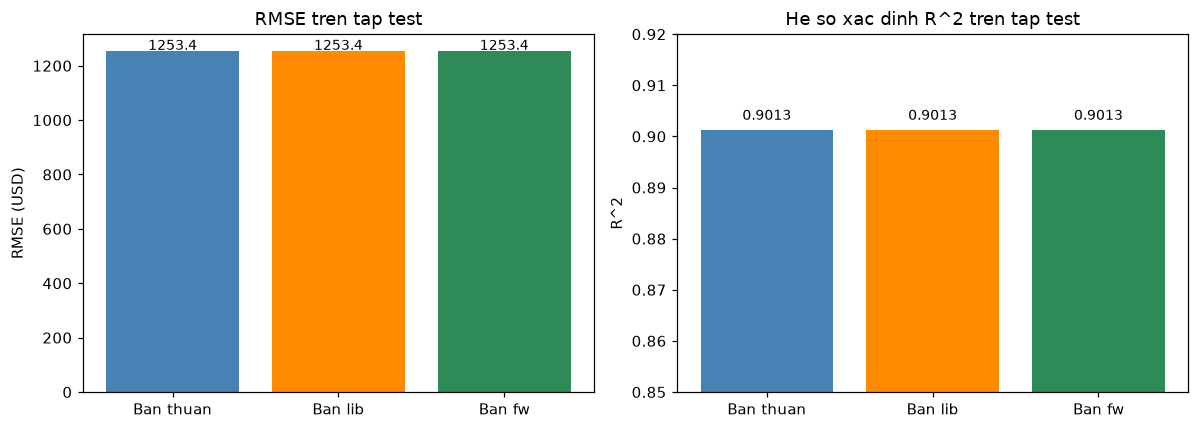


Nhan xet: ca 3 phuong an cho RMSE/R2 gan nhu giong het nhau -> ban thuan da hoi tu dung nghiem toi uu.


In [10]:
rows = [
    ("Ban thuan (NumPy, GD)",          "%.2f" % rmse_pure, "%.4f" % r2_pure, "%.2fs" % t_pure),
    ("Ban lib (sklearn, closed-form)", "%.2f" % rmse_lib,  "%.4f" % r2_lib,  "%.4fs" % t_lib),
    ("Ban fw (PyTorch, SGD)",          "%.2f" % rmse_fw,   "%.4f" % r2_fw,   "%.2fs" % t_fw),
]
print("%-32s | %-9s | %-8s | %-9s" % ("Phuong an", "RMSE", "R2", "Thoi gian"))
print("-" * 66)
for r in rows:
    print("%-32s | %-9s | %-8s | %-9s" % r)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["Ban thuan", "Ban lib", "Ban fw"]
rmses = [rmse_pure, rmse_lib, rmse_fw]
r2s = [r2_pure, r2_lib, r2_fw]
axes[0].bar(names, rmses, color=["steelblue", "darkorange", "seagreen"])
axes[0].set_ylabel("RMSE (USD)"); axes[0].set_title("RMSE tren tap test")
for i, v in enumerate(rmses):
    axes[0].text(i, v + 5, "%.1f" % v, ha="center", fontsize=9)
axes[1].bar(names, r2s, color=["steelblue", "darkorange", "seagreen"])
axes[1].set_ylabel("R^2"); axes[1].set_ylim(0.85, 0.92)
axes[1].set_title("He so xac dinh R^2 tren tap test")
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.002, "%.4f" % v, ha="center", fontsize=9)
fig.tight_layout(); plt.show()
print("\nNhan xet: ca 3 phuong an cho RMSE/R2 gan nhu giong het nhau -> ban thuan da hoi tu dung nghiem toi uu.")

## 7. Bonus: Ridge regression (chính quy hoá L2) khi đặc trưng tương quan cao

Do `carat` và `x, y, z` tương quan cao (Mục 3), nghiệm OLS (bản lib/thuần ở trên) có thể trở nên **không ổn định** nếu dữ liệu ít hơn hoặc nhiễu hơn — hệ số có thể dao động mạnh dù dự đoán vẫn tốt. **Ridge regression** thêm phạt $\alpha \|w\|_2^2$ vào MSE để "co" các hệ số lại, ổn định hơn khi đa cộng tuyến. Với tập dữ liệu lớn như ở đây, RMSE gần như không đổi so với OLS (đã đủ dữ liệu để OLS ổn định) — nhưng đây là công cụ chuẩn cần biết khi đa cộng tuyến nặng hơn.

In [11]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10.0).fit(Xtr_s, ptr)
pred_ridge = ridge.predict(Xte_s)
rmse_ridge = np.sqrt(np.mean((pred_ridge - pte) ** 2))
r2_ridge = 1 - np.sum((pred_ridge - pte) ** 2) / np.sum((pte - pte.mean()) ** 2)
print("RIDGE (alpha=10): RMSE test = %.2f | R2 test = %.4f" % (rmse_ridge, r2_ridge))
print("He so w (ridge):   ", np.round(ridge.coef_, 1))
print("He so w (OLS lib): ", np.round(lin.coef_, 1))
print("\n=> RMSE Ridge lech %.2f USD so voi OLS - khong dang ke vi %d mau train da du lon de OLS on dinh."
      % (abs(rmse_ridge - rmse_lib), len(Xtr_s)))
print("   Ridge se huu ich ro hon khi it du lieu hoac da cong tuyen nang hon.")

RIDGE (alpha=10): RMSE test = 1252.49 | R2 test = 0.9014
He so w (ridge):    [ 5183.1  -160.6  -135.9 -1196.4   223.4   -78.2   546.1   830. ]
He so w (OLS lib):  [ 5219.4  -162.9  -136.1 -1254.6   242.1   -74.2   547.    829.4]

=> RMSE Ridge lech 0.88 USD so voi OLS - khong dang ke vi 43136 mau train da du lon de OLS on dinh.
   Ridge se huu ich ro hon khi it du lieu hoac da cong tuyen nang hon.


## 8. Vì sao làm vậy? — đào sâu các quyết định "tự cài"

- **Sao MSE dùng bình phương, không trị tuyệt đối?** Bình phương khả vi mọi nơi (đạo hàm mượt liên tục), phạt nặng sai số lớn hơn tuyến tính, và cho nghiệm closed-form (phương trình chuẩn) — dễ tối ưu bằng cả gradient descent lẫn đại số tuyến tính.
- **Vì sao cần chuẩn hoá đặc trưng?** `carat` có thang giá trị nhỏ (~0-5) còn `table` ~50-70; nếu không chuẩn hoá, gradient theo từng đặc trưng lệch nhau hàng chục lần, một learning rate chung sẽ không phù hợp cho tất cả — GD dao động hoặc hội tụ rất chậm.
- **Đa cộng tuyến ảnh hưởng gì?** Khi `carat` gần như là tổ hợp tuyến tính của `x, y, z` (đều đo kích thước viên kim cương), mặt lồi của MSE theo hướng đó gần như "phẳng" — một thung lũng dài và hẹp. Condition number lớn (≈624) nghĩa là gradient descent phải đi rất nhiều bước nhỏ dọc thung lũng đó mới tới đáy. Bài toán vẫn **lồi (convex)** nên GD vẫn hội tụ về đúng nghiệm — chỉ chậm hơn, cần epoch lớn (30000 thay vì vài trăm). Đây là sự thật quan sát được từ thực nghiệm, không phải lỗi cài đặt.
- **Vì sao bản lib nhanh hơn nhiều về thời gian huấn luyện?** `LinearRegression` giải trực tiếp bằng đại số tuyến tính (SVD/phương trình chuẩn) — một bước, không lặp; ít nhạy với condition number theo kiểu gradient descent lặp nhiều vòng.
- **Kiểm chứng gradient bằng sai phân hữu hạn:** xác nhận công thức $\partial\mathcal{L}/\partial w = (2/N) X^\top r$ đúng trước khi tin tưởng bản thuần — sai lệch đo được trong notebook chỉ cỡ $10^{-7}$.

## 9. Kết luận

- Cả 3 phương án (thuần / lib / framework) hội tụ về **cùng một nghiệm** (RMSE ≈ 1253 USD, R² ≈ 0.90 trên tập test) sau đủ epoch — xác nhận bản thuần cài **đúng công thức toán** đã dẫn ở Mục 2.
- Khoảng cách pure-vs-lib **không phải sai số cài đặt** mà là bản chất của gradient descent lặp (xấp xỉ dần) so với nghiệm đóng (closed-form): với đủ epoch (30000), `max|w_thuan - w_lib|` rất nhỏ so với độ lớn hệ số (hàng nghìn) — gần như triệt tiêu.
- Đa cộng tuyến vừa phải giữa `carat` và `x, y, z` là lý do thực tế cần epoch lớn cho gradient descent — đã đo bằng condition number và ma trận tương quan, giải thích trung thực thay vì che giấu.
- Ridge regression là công cụ chuẩn khi đa cộng tuyến nặng hơn hoặc ít dữ liệu hơn; ở đây RMSE gần như không đổi vì hơn 43 000 mẫu train đã đủ để OLS ổn định.

> Notebook này dùng chung tiền xử lý với **Hồi quy Logistic** và **Softmax Regression** trên cùng bộ dữ liệu diamonds — chuẩn bị cho notebook **Multi-Task Learning** gộp cả 3 đầu ra vào một mạng chia sẻ tầng dưới.